# Qwen2-VL-2B Model Evaluation

This notebook evaluates the performance of Qwen-VL-2.5B model on our fire detection dataset.

In [1]:
# For virtual environment only, ignore this cell if you're using personal computer
!source ../../miniconda3/bin/activate
!conda --version

conda 24.11.3


In [2]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
from transformers import AutoModelForImageTextToText, AutoTokenizer, AutoProcessor
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
from qwen_vl_utils import process_vision_info
import matplotlib.pyplot as plt
import time
import re, json

In [3]:
# Load ground truth data
df = pd.read_csv('../fire_captions_combined.csv')
print(f"Total samples in dataset: {len(df)}")
df.head()

Total samples in dataset: 2145


,image_path,label,caption
0,fire_dataset_combined/image1.jpg,no fire,The image shows a cozy living room with a fire...
1,fire_dataset_combined/image2.jpg,no fire,The image shows a neatly arranged bedroom with...
2,fire_dataset_combined/image3.jpg,no fire,The image shows a dining area with a wooden ta...
3,fire_dataset_combined/image4.jpg,no fire,The image shows a modern office space with lar...
4,fire_dataset_combined/image5.jpg,no fire,The image shows a hospital room with a patient...


In [5]:
# Initialize model and processor
model_name = "Qwen/Qwen2-VL-2B-Instruct"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForImageTextToText.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True
)

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

In [ ]:
def process_image(image_path):
    """Process a single image and return the model's prediction, caption and inference time"""
    try:
        # Start timing
        start_time = time.time()
        
        # Load image
        image = Image.open(image_path).convert("RGB")
        
        # Fire analysis prompt
        system_prompt = (
            "You are a visual analyst evaluating an image for signs of fire and the surrounding context. "
            "Do the following tasks:\n"
            "1: Summarize what you see in the image. Describe the environment, key objects, people, and any signs of fire or smoke.\n"
            "2: Based on your summary, classify the fire situation: "
            "no fire(e.g., fire alarm, fire distinguisher,..), controlled fire (e.g., fireplace emitting, campfire, cooking, candles, match stick, lighter..) "
            "or a dangerous/uncontrolled fire (e.g., curtains on fire, smoke on ceiling, couch on fire, bed sheet on fire, spreading fire on furniture..)?\n"
            "Return only this JSON format:\n"
            '{ "caption": "...", "label": "no fire"|"controlled fire"|"dangerous fire" }'
        )

        messages = [{
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": system_prompt}
            ]
        }]

        # Generate prompt and inputs
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages) #this is for qwen family only, for other models please remove
        inputs = processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        ).to(device)

        # Generate response
        with torch.no_grad():
            generate_ids = model.generate(
                **inputs,
                max_new_tokens=1024,
                do_sample=True,
                top_k=50,
                top_p=0.95,
                num_return_sequences=1,
            )
        
        output = processor.tokenizer.batch_decode(generate_ids, skip_special_tokens=True)[0]
        if output.startswith("system"):
            output = output.split("assistant", 1)[-1].strip()

        clean_output = re.sub(r'^(system|user|assistant)\n', '', output, flags=re.MULTILINE).strip()

        # Match the last complete JSON block
        matches = re.findall(r'\{[^{}]+\}', clean_output, re.DOTALL)
        if matches:
            try:
                result = json.loads(matches[-1])  # take the last match (most likely correct)
                caption = result.get("caption", "").strip()
                label = result.get("label", "").strip()
            except Exception as e:
                print(f"❌ Failed to parse JSON for {image_path}: {e}")
                caption = clean_output
                label = "unknown"
        else:
            print(f"❌ No JSON block found in output for {image_path}")
            caption = clean_output
            label = "unknown"

        # Calculate inference time
        inference_time = time.time() - start_time
        
        return label, caption, inference_time
            
    except Exception as e:
        print(f"Error processing {image_path}: {str(e)}")
        return "error", "", 0.0

In [10]:
# Process all images and collect predictions
predictions = []
captions = []
inference_times = []
ground_truth = []

for idx, row in df.iterrows():
    img_path = os.path.join('../', row['image_path'])
    if os.path.exists(img_path):
        pred, caption, inf_time = process_image(img_path)
        predictions.append(pred)
        captions.append(caption)
        inference_times.append(inf_time)
        ground_truth.append(row['label'])
        if idx % 10 == 0:
            print(f"Processed {idx} images... Average inference time so far: {np.mean(inference_times):.3f}s")

print(f"\nProcessing complete! Average inference time: {np.mean(inference_times):.3f}s")

Processed 0 images... Average inference time so far: 1.554s
Processed 10 images... Average inference time so far: 1.590s
Processed 20 images... Average inference time so far: 1.546s
Processed 30 images... Average inference time so far: 1.574s
Processed 40 images... Average inference time so far: 1.580s
Processed 50 images... Average inference time so far: 1.578s
Processed 60 images... Average inference time so far: 1.584s
Processed 70 images... Average inference time so far: 1.592s
Processed 80 images... Average inference time so far: 1.591s
Processed 90 images... Average inference time so far: 1.584s
Processed 100 images... Average inference time so far: 1.599s
Processed 110 images... Average inference time so far: 1.597s
Processed 120 images... Average inference time so far: 1.600s
Processed 130 images... Average inference time so far: 1.601s
Processed 140 images... Average inference time so far: 1.597s
Processed 150 images... Average inference time so far: 1.597s
Processed 160 image

In [11]:
# Calculate metrics
accuracy = accuracy_score(ground_truth, predictions)
precision, recall, f1, _ = precision_recall_fscore_support(
    ground_truth, 
    predictions, 
    average='weighted'
)

print("Model Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"\nInference Time Statistics:")
print(f"Average: {np.mean(inference_times):.3f}s")
print(f"Std Dev: {np.std(inference_times):.3f}s")
print(f"Min: {np.min(inference_times):.3f}s")
print(f"Max: {np.max(inference_times):.3f}s")

Model Performance Metrics:
Accuracy: 0.9371
Precision: 0.9501
Recall: 0.9371
F1 Score: 0.9404

Inference Time Statistics:
Average: 1.636s
Std Dev: 0.953s
Min: 0.983s
Max: 13.163s


/home/student4/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


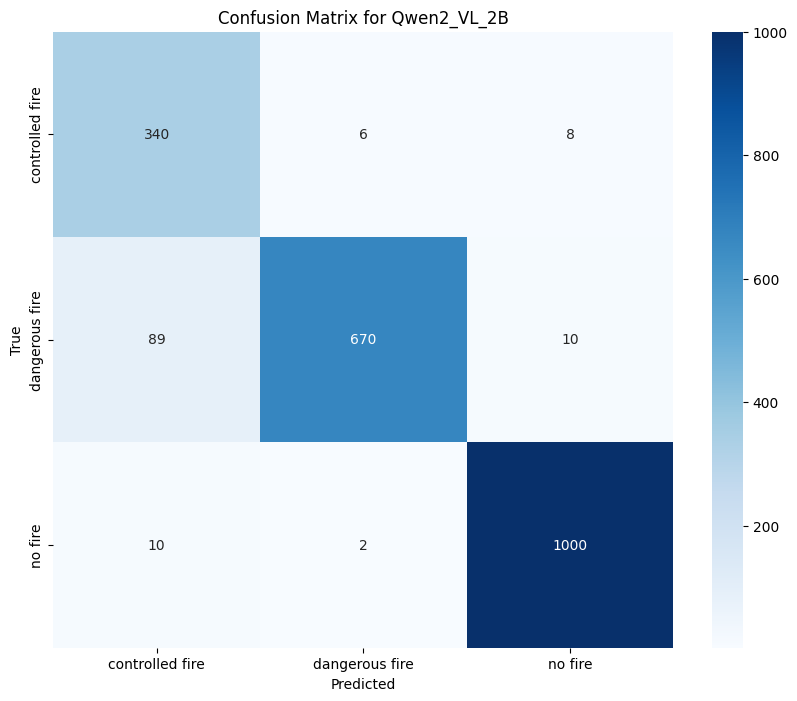

In [14]:
# Create and plot confusion matrix
labels = sorted(list(set(ground_truth)))
cm = confusion_matrix(ground_truth, predictions, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title('Confusion Matrix for Qwen2_VL_2B')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Results saved to qwen_vl_2B_results.csv


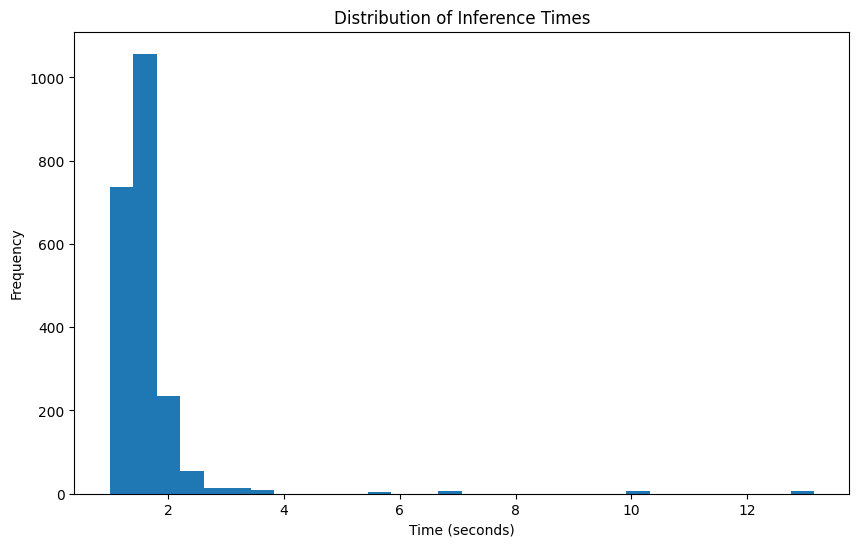

In [13]:
# Save results to CSV
results_df = pd.DataFrame({
    'image_path': df['image_path'],
    'true_label': ground_truth,
    'predicted_label': predictions,
    'caption': captions,
    'inference_time': inference_times,
    'correct': [t == p for t, p in zip(ground_truth, predictions)]
})

results_df.to_csv('qwen2_vl_2B_results.csv', index=False)
print("Results saved to qwen_vl_2B_results.csv")

# Display inference time distribution
plt.figure(figsize=(10, 6))
plt.hist(inference_times, bins=30)
plt.title('Distribution of Inference Times')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.show()